# NovaPay Fraud Transaction Detection

## Data Cleaning and Exploratory Data Analysis

This notebook prepares NovaPay transaction data for fraud modelling. It documents the workflow from initial inspection and data-quality treatment through exploratory analysis and the first stage of modelling preparation.

### Objectives

- Inspect the structure and quality of the raw data.
- Correct invalid data types and inconsistent categories.
- Treat missing and invalid values using defensible rules.
- Examine numerical, categorical, and interaction patterns associated with fraud.
- Preserve a reproducible cleaned dataset for subsequent modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None) # to display all the columns in the dataframe

In [3]:
transactions_df= pd.read_csv('../data/nova_pay_combined.csv')

## 1. Dataset Overview

This section establishes the size, structure, data types, completeness, and initial statistical characteristics of the raw transaction dataset.

### 1.1 Initial Inspection

The following checks preview the records, confirm the dataset dimensions, inspect the schema, review category frequencies, quantify missing values, identify exact duplicate rows, and summarise numerical and categorical variables.

In [4]:
transactions_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
transactions_df.shape # to check the number of rows and columns in the dataset

(11400, 26)

In [6]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [7]:
for col in transactions_df.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(transactions_df[col].value_counts())
    print('--------------------')

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
                                       ..
b5ef3323-46d2-4f6c-9c19-43df4e55df48    1
54f00f78-94aa-4a08-bf6b-12877aa47186    1
6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5    1
4aad7389-2b62-4885-a23e-aa3ecd5cfaf9    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: count, Length: 11200, dtype: int64
--------------------
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
8734e6a7-f34e-49f2-b559-1d62a756664c       1
c18070a6-bdb9-4df3-9df7-5d92c0bff424       1
2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca       1
8b1cf558-4ed7-48ee-b330-75db6efd4840       1

In [8]:
missing_summary = pd.DataFrame({
    'missing_count': transactions_df.isnull().sum(),
    'missing_percentage': transactions_df.isnull().mean() * 100
})

missing_summary

,missing_count,missing_percentage
transaction_id,0,0.000000
customer_id,0,0.000000
timestamp,29,0.254386
home_country,0,0.000000
source_currency,0,0.000000
dest_currency,0,0.000000
channel,0,0.000000
amount_src,0,0.000000
amount_usd,305,2.675439
fee,295,2.587719


In [9]:
transactions_df.duplicated().sum() # to check for duplicate rows in the dataset


np.int64(200)

In [10]:
transactions_df.describe() # to get the statistical summary of the dataset


,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [11]:
transactions_df.describe(include= ['str','bool']) # to get the statistical summary of the categorical columns

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,device_id,new_device,ip_address,ip_country,location_mismatch,kyc_tier
count,11400,11400,11371,11400,11400,11400,11400,11400,11400,11400,11095,11099,11400,11100
unique,11200,1315,11141,7,3,9,12,9856,2113,2,10900,9,2,14
top,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,0000-00-00T00:00:00Z,US,USD,NGN,mobile,100.0,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,194.179.17.152,US,False,standard
freq,2,1510,21,7940,8031,1474,6366,15,87,10047,2,6848,9548,7931


## 2. Data Cleaning and Quality Assessment

### 2.1 Correcting Data Types

The `timestamp` field is converted to a timezone-aware datetime type, while `amount_src` is converted to a numerical type. Invalid values are coerced to missing values so they can be investigated and treated consistently.

In [12]:
transactions_df['timestamp']= pd.to_datetime(transactions_df['timestamp'], errors='coerce') # convert the timestamp column to datetime format
transactions_df['amount_src'] =pd.to_numeric(transactions_df['amount_src'], errors='coerce') # convert the amount_src column to numeric format

In [13]:
transactions_df[['amount_src', 'timestamp']].dtypes

amount_src                float64
timestamp     datetime64[us, UTC]
dtype: object

In [14]:
transactions_df['is_fraud'].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

### 2.2 Target Distribution and Class-Imbalance Note

The target variable is binary: `0` represents a legitimate transaction and `1` represents fraud. The class distribution is reviewed here to establish the degree of imbalance.

Any balancing method, including SMOTE, should be applied later **only to the training data** after the train/test split. Applying it before splitting would introduce data leakage.

### 2.3 Missing-Value Assessment

Columns containing missing values are identified and ranked by their missing-value percentage. This establishes which variables require treatment and helps determine whether imputation or row removal is appropriate.

In [15]:
# Get the list of columns that contain at least one missing value
null_columns = transactions_df.isnull().mean() * 100 > 0 #  creates a true/false filter 
null_columns[null_columns == True].index.tolist() #returns the name of columns with missing values

['timestamp',
 'amount_src',
 'amount_usd',
 'fee',
 'ip_address',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

### 2.4 Duplicate Records

Exact duplicate rows are checked separately from repeated identifiers. A customer may legitimately appear in many transactions, while a transaction identifier is generally expected to be unique.

> **Implementation note:** `drop_duplicates()` returns a new DataFrame unless the result is assigned back or `inplace=True` is used.

In [16]:
transactions_df.duplicated().sum()


np.int64(200)

In [17]:
duplicates = transactions_df[transactions_df.duplicated(keep='first')].sort_values(by='transaction_id') # to display the duplicate rows in the dataset
duplicates.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10153,03368cab-696b-4984-bffb-3429267e57b2,7bd5200c-5d19-44f0-9afe-8b339a05366b,2024-06-29 04:15:54.468549+00:00,US,USD,GBP,ATM,299.24,299.24,4.70,0.800000,3104801a-ba96-4c81-9aef-97a6f8838548,False,168.133.242.223,US,False,0.202,standard,147,0.551,0,0.391,0,0,0.0,0
10079,0368fc3c-2323-470e-aafe-eb0d920553eb,d71c91b4-fee8-4104-9856-a5c6109a62e3,2024-08-16 14:03:44.468549+00:00,US,USD,EUR,mobile,118.40,118.40,2.82,0.925926,4449e051-711b-4309-befc-a0c57b1e5a4c,False,171.154.22.226,US,False,0.154,standard,298,0.336,0,0.166,0,0,0.0,0
10036,04532993-f980-4c87-9129-373a00ed57db,d71c91b4-fee8-4104-9856-a5c6109a62e3,2024-04-18 10:26:16.468549+00:00,US,USD,PHP,mobile,438.81,438.81,6.98,58.823529,2007d94d-6881-4e93-884f-4590cf2ebf34,False,111.113.205.126,US,False,0.310,standard,298,0.336,0,0.166,0,0,0.1,0
10085,061c3f56-bff6-47d9-b195-1ecdc1faee8a,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2024-10-06 05:17:22.468549+00:00,US,USD,MXN,mobile,82.11,82.11,1.95,17.241379,f9747f4b-629b-4148-8cbc-7b030fd58177,False,201.150.66.7,US,False,0.385,standard,1018,0.934,0,0.087,0,0,0.2,0
10136,068abac2-c06a-42af-9a38-379886b26e4a,d71c91b4-fee8-4104-9856-a5c6109a62e3,2023-07-14 03:58:42.468549+00:00,US,USD,USD,mobille,91.31,91.31,0.96,1.000000,4449e051-711b-4309-befc-a0c57b1e5a4c,False,203.54.129.225,unknown,False,0.362,standard,298,0.336,0,0.166,0,0,0.0,0


In [18]:
transactions_df.drop_duplicates()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,1.351351,5c06f00d-a089-402b-9b14-e7bc7ae56ed2,False,221.126.239.197,US,False,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,822.222222,dafd943c-f12f-48b9-83df-401efaad0fe3,False,26.6.123.44,UK,True,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,61.666667,94475656-37f3-4b9c-b3cd-6d89416866ac,True,184.150.56.237,US,True,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,0eab90ef-4273-4239-8b51-2c96b2a24756,False,31.125.175.93,US,False,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0


### 2.5 Standardising Categorical Values

Text categories are converted to lowercase and stripped of surrounding whitespace. Known spelling errors and inconsistent labels are then corrected so that equivalent categories are not treated as separate values.

In [19]:
category_columns = transactions_df.select_dtypes(include=['str', 'object']).columns.tolist()

for col in category_columns:
    transactions_df[col] = transactions_df[col].str.lower().str.strip()

corrections = {'channel':{'mobille': 'mobile', 'weeb': 'web'}, 'kyc_tier': {'standrd': 'standard','enhancd': 'enhanced', 'nan':'unknown'}, 'ip_country':{'nan': 'unknown'}}

for column, corrections in corrections.items():
    transactions_df[column] = transactions_df[column].replace(corrections)

### 2.6 Missing Values After Standardisation

Missingness is reassessed after data-type conversion and category standardisation because invalid strings may have been converted to `NaN` during cleaning.

In [20]:
transactions_df['timestamp'].isnull().sum()

np.int64(61)

In [21]:
transactions_df.shape

(11400, 26)

## 3. Missing-Value Treatment

Each variable is treated according to its meaning, available supporting information, and proportion of missing records. Imputation is based on defensible relationships rather than a single method applied to every column.

In [22]:
missing_summary = pd.DataFrame({
    'missing_count': transactions_df.isnull().sum(),
    'missing_percentage': transactions_df.isnull().mean() * 100
})

missing_summary

,missing_count,missing_percentage
transaction_id,0,0.000000
customer_id,0,0.000000
timestamp,61,0.535088
home_country,0,0.000000
source_currency,0,0.000000
dest_currency,0,0.000000
channel,0,0.000000
amount_src,4,0.035088
amount_usd,305,2.675439
fee,295,2.587719


### 3.1 Timestamp

Rows with missing timestamps are reviewed before removal because transaction time cannot be reconstructed reliably from the remaining variables.

In [23]:
# We drop timestamp mossing rows since i tis very little -0.5%: better reason 
transactions_df['timestamp'].isnull().sum()
    

np.int64(61)

In [24]:
transactions_df = transactions_df.dropna(subset=['timestamp'])
transactions_df = transactions_df.reset_index(drop=True)

The timestamp column contains a very small proportion of missing observations. Because transaction time is required for temporal analysis and cannot be imputed reliably, those rows are removed and the index is reset.

### 3.2 Source and USD Transaction Amounts

Missing values in `amount_src` and `amount_usd` are investigated using `source_currency` and the relationship between the source amount and its USD equivalent. Existing complete transactions provide a reference rate for each source currency.

In [25]:
# Find rows where amount_src is missing and group by source_currency to see how many missing values are there for each currency
transactions_df[transactions_df['amount_src'].isnull()]['source_currency'].value_counts()

source_currency
usd    3
gbp    1
Name: count, dtype: int64

In [26]:
# Find rows where amount_src is missing and display relevant columns
transactions_df[transactions_df['amount_src'].isnull()][['source_currency','amount_src','amount_usd','exchange_rate_src_to_dest']]

,source_currency,amount_src,amount_usd,exchange_rate_src_to_dest
4783,gbp,NaN,12498.57,1.689189
7985,usd,NaN,9995.95,1.000000
8822,usd,NaN,1541.55,83.333333
9386,usd,NaN,9991.24,1.351351


In [27]:
# Condition: amount_src is missing, source currency is USD, and amount_usd exists
usd_missing_src = (
    transactions_df['amount_src'].isna() &
    (transactions_df['source_currency'] == 'usd') &
    (transactions_df['amount_usd'].notna())
)

# Fill missing amount_src using amount_usd for USD rows
transactions_df.loc[usd_missing_src, 'amount_src'] = transactions_df.loc[usd_missing_src, 'amount_usd']

In [28]:
transactions_df[transactions_df['amount_src'].isnull()][[
    'source_currency',
    'amount_src',
    'amount_usd',
    'exchange_rate_src_to_dest'
]]

,source_currency,amount_src,amount_usd,exchange_rate_src_to_dest
4783,gbp,NaN,12498.57,1.689189


In [29]:
transactions_df[['amount_src', 'source_currency', 'amount_usd', 'exchange_rate_src_to_dest']]

,amount_src,source_currency,amount_usd,exchange_rate_src_to_dest
0,278.19,usd,278.19,1.351351
1,208.51,cad,154.29,12.758621
2,160.33,usd,160.33,7.142857
3,59.41,usd,59.41,0.925926
4,200.96,usd,200.96,83.333333
...,...,...,...,...
11334,271.25,usd,271.25,1.351351
11335,537.17,cad,397.51,822.222222
11336,205.15,cad,151.81,61.666667
11337,78.03,usd,78.03,58.823529


#### Estimating Source-to-USD Rates by Currency

For complete transactions, the source-to-USD rate is estimated from the relationship between `amount_usd` and the absolute source amount. The median rate for each source currency is used because it is less sensitive to extreme values.

In [30]:
transactions_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


For a complete transaction:

`source_usd_rate = amount_usd / abs(amount_src)`

For a missing USD amount:

`amount_usd = abs(amount_src) × source_usd_rate`

For a missing source amount:

`amount_src = amount_usd / source_usd_rate`

The procedure is:

1. Select rows where both amount fields are available.
2. Calculate the source-to-USD rate for each complete row.
3. Group rates by `source_currency`.
4. Use the median rate for each currency.
5. Map the rate back to the full dataset and fill the missing amount values.

In [31]:
transactions_df['amount_usd'].isnull().sum() 
# missing rows in amount usd   

np.int64(305)

The number of missing `amount_usd` observations is checked before imputation so that the result can be verified afterwards.

#### Building the Reference Dataset

Only rows with both `amount_src` and `amount_usd` available are used to estimate currency-specific reference rates.

In [32]:
completed_rows = transactions_df[transactions_df['amount_usd'].notnull()&transactions_df['amount_src'].notnull()].copy()

In [33]:
completed_rows ['source_usd_rate']= (completed_rows['amount_usd'] / completed_rows['amount_src']).abs()
# absolute because amount_usd is + 

In [34]:
source_usd_rate=(completed_rows.groupby('source_currency')['source_usd_rate'].median())

In [35]:
print(source_usd_rate)


source_currency
cad    0.74
gbp    1.25
usd    1.00
Name: source_usd_rate, dtype: float64


In [36]:
transactions_df['source_usd_rate'] = (transactions_df['source_currency'].map(source_usd_rate))

In [37]:
transactions_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,source_usd_rate
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,1.00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,0.74
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,1.00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1.00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,1.00


In [38]:
#Filling the missing ammount_usd  
missing_usd_rows = transactions_df['amount_usd'].isnull()

transactions_df.loc[missing_usd_rows, 'amount_usd'] = (
transactions_df.loc[missing_usd_rows, 'amount_src'].abs() * transactions_df.loc[missing_usd_rows, 'source_usd_rate']
)

#round up the amount_usd to 2 decimal places
transactions_df['amount_usd'] = transactions_df['amount_usd'].round(2)

In [39]:
transactions_df['amount_usd'].isnull().sum()
transactions_df.loc[transactions_df['amount_usd'].isnull()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,source_usd_rate


In [40]:
transactions_df['amount_src'].isnull().sum()
transactions_df.loc[transactions_df['amount_src'].isnull()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,source_usd_rate
4783,95df4052-29be-470f-87f9-61e5173370b2,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-03-12 08:48:06.468549+00:00,uk,gbp,cad,mobile,NaN,12498.57,-1.0,1.689189,99c6f35d-9b07-429c-9992-216a8051b250,True,231.92.71.11,uk,False,1.2,standard,4,-0.1,0,0.407,-1,0,0.0,0,1.25


In [41]:
#amount_usd = abs(amount_src)* sourtce_usd_rate

#amount src = amount_usd + source_usdf -rate 

# filling missing amiount_src using amout_usd and source_usd_rate 
missing_src_rows = transactions_df['amount_src'].isnull()

transactions_df.loc[missing_src_rows, 'amount_src'] = (
    transactions_df.loc[missing_src_rows, 'amount_usd'].abs() / transactions_df.loc[missing_src_rows, 'source_usd_rate']
)

### 3.3 Fee Validation and Imputation

The fee field is assessed for missingness, unusual sentinel values, and its relationship with the absolute source transaction amount. Only valid fee observations are used to estimate the typical fee rate.

In [42]:
transactions_df.groupby(transactions_df['fee'].isnull())['is_fraud'].mean()

fee
False    0.089370
True     0.027119
Name: is_fraud, dtype: float64

A binary indicator is created before imputation to preserve whether the fee was originally missing. This can later be evaluated as a potential predictive feature.

In [43]:
transactions_df['fee'].isnull().sum()

np.int64(295)

In [44]:
transactions_df[['channel','fee']]

,channel,fee
0,atm,4.25
1,web,4.24
2,mobile,2.70
3,mobile,2.22
4,mobile,3.61
...,...,...
11334,mobile,5.24
11335,web,8.86
11336,web,4.00
11337,mobile,1.96


Missing and invalid fee values were identified during the data-quality assessment. The repeated values `-1` and `9999.99` produced negative or commercially implausible fee-to-transaction ratios and were therefore treated as invalid sentinel values.

Valid fees had a median fee-to-source-amount ratio of approximately **2.05%**. Missing and invalid fees were estimated using this global median ratio and the absolute source amount:

`estimated_fee = abs(amount_src) × median_fee_rate`

The original missing and invalid conditions were recorded before repair so that the cleaning process remained auditable.

In [45]:
# Record the original fee problems
transactions_df['fee_was_missing'] = (
    transactions_df['fee'].isnull()
)

transactions_df['fee_was_invalid'] = (
    (transactions_df['fee'] < 0) |
    (transactions_df['fee'] == 9999.99)
)

# Identify all fees requiring repair
fee_needs_repair = (
    transactions_df['fee'].isnull() |
    (transactions_df['fee'] < 0) |
    (transactions_df['fee'] == 9999.99)
)

# Select valid rows for calculating the usual fee rate
valid_fee_rows = (
    ~fee_needs_repair &
    transactions_df['amount_src'].notnull() &
    (transactions_df['amount_src'].abs() > 0)
)

# Calculate valid fee-to-source-amount ratios
valid_fee_rates = (
    transactions_df.loc[valid_fee_rows, 'fee']
    /
    transactions_df.loc[
        valid_fee_rows,
        'amount_src'
    ].abs()
)

# Calculate the global median fee rate
median_fee_rate = valid_fee_rates.median()

print(f"Median fee rate: {median_fee_rate:.2%}")

# Repair missing and invalid fees
transactions_df.loc[fee_needs_repair, 'fee'] = (
    transactions_df.loc[
        fee_needs_repair,
        'amount_src'
    ].abs()
    * median_fee_rate
)

# Round fees to two decimal places
transactions_df['fee'] = (
    transactions_df['fee'].round(2)
)

Median fee rate: 2.05%


In [46]:
print(
    "Originally missing fees:",
    transactions_df['fee_was_missing'].sum()
)

print(
    "Originally invalid fees:",
    transactions_df['fee_was_invalid'].sum()
)

print(
    "Remaining missing fees:",
    transactions_df['fee'].isnull().sum()
)

print(
    "Remaining invalid fees:",
    (
        (transactions_df['fee'] < 0) |
        (transactions_df['fee'] == 9999.99)
    ).sum()
)

Originally missing fees: 295
Originally invalid fees: 204
Remaining missing fees: 0
Remaining invalid fees: 0


In [47]:
transactions_df['fee'].isnull().sum()

np.int64(0)

### 3.4 KYC Tier

Missing or unknown KYC tiers are investigated using other transactions from the same customer. A customer-level value is used only where the known KYC information is consistent; unresolved cases remain labelled `unknown`.

In [48]:
transactions_df['kyc_tier'].isnull().sum()

np.int64(300)

In [49]:
# Identify missing or unknown KYC values
missing_kyc = (
    transactions_df['kyc_tier'].isnull() |
    transactions_df['kyc_tier'].eq('unknown')
)

# Use only known KYC values
known_kyc = transactions_df[
    ~missing_kyc &
    transactions_df['customer_id'].notnull()
]

# Create a mapping only for customers with one consistent KYC tier
customer_kyc_mapping = (
    known_kyc
    .groupby('customer_id')['kyc_tier']
    .agg(
        lambda values:
        values.iloc[0] if values.nunique() == 1 else pd.NA
    )
)

# Fill missing KYC using another transaction from the same customer
transactions_df.loc[missing_kyc, 'kyc_tier'] = (
    transactions_df.loc[missing_kyc, 'customer_id']
    .map(customer_kyc_mapping)
)

# Fill values that could not be recovered
transactions_df['kyc_tier'] = (
    transactions_df['kyc_tier']
    .fillna('unknown')
)

# Verify
transactions_df['kyc_tier'].value_counts(dropna=False)



kyc_tier
standard    8350
enhanced    1928
low         1059
unknown        2
Name: count, dtype: int64

In [50]:
transactions_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,source_usd_rate,fee_was_missing,fee_was_invalid
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,1.00,False,False
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,0.74,False,False
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,1.00,False,False
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1.00,False,False
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,1.00,False,False


In [51]:
transactions_df['kyc_tier'].value_counts()

kyc_tier
standard    8350
enhanced    1928
low         1059
unknown        2
Name: count, dtype: int64

### 3.5 IP Country

A missing `ip_country` is replaced with `home_country` only when `location_mismatch` is `False`. Any value that remains unresolved is labelled `unknown`, avoiding an unsupported assumption when a location mismatch is present.

In [52]:
# Find missing ip_country values
missing_ip_country = transactions_df['ip_country'].isnull()

# Fill from home_country only when location_mismatch is False
fill_from_home_country = (
    missing_ip_country &
    transactions_df['location_mismatch'].eq(False)
)

In [53]:
transactions_df.loc[
    fill_from_home_country,
    'ip_country'
] = transactions_df.loc[
    fill_from_home_country,
    'home_country'
]

In [54]:
# Fill any remaining missing ip_country values with 'unknown'
transactions_df['ip_country'] = (
    transactions_df['ip_country'].fillna('unknown')
)
transactions_df['ip_country'].isnull().sum()

np.int64(0)

In [55]:
transactions_df['kyc_tier'].isnull().sum()


np.int64(0)

### 3.6 Device Trust Score

The relationship between device trust and relevant categorical variables is reviewed before imputation. Missing device-trust scores are filled using the median within `kyc_tier` and `location_mismatch` groups, with the global median used only as a fallback.

In [56]:
transactions_df.groupby('location_mismatch')['device_trust_score'].median()

location_mismatch
False    0.744
True     0.522
Name: device_trust_score, dtype: float64

In [57]:
transactions_df.groupby('channel')['device_trust_score'].median()

channel
atm        0.6270
mobile     0.7420
unknown    0.6605
web        0.6070
Name: device_trust_score, dtype: float64

In [58]:
transactions_df.groupby('kyc_tier')['device_trust_score'].median()

kyc_tier
enhanced    0.920
low         0.457
standard    0.551
unknown       NaN
Name: device_trust_score, dtype: float64

In [59]:
# Create missing indicator first
transactions_df['device_trust_score_missing'] = (
    transactions_df['device_trust_score'].isnull()
)

# Fill missing device trust score using grouped median
transactions_df['device_trust_score'] = transactions_df['device_trust_score'].fillna(
    transactions_df.groupby(['kyc_tier', 'location_mismatch'])['device_trust_score']
    .transform('median')
)

# Backup fill in case any group median is still missing
transactions_df['device_trust_score'] = transactions_df['device_trust_score'].fillna(
    transactions_df['device_trust_score'].median()
)

In [60]:
transactions_df['device_trust_score'].isnull().sum()

np.int64(0)

In [61]:
transactions_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,source_usd_rate,fee_was_missing,fee_was_invalid,device_trust_score_missing
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,1.00,False,False,False
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,0.74,False,False,False
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,1.00,False,False,False
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1.00,False,False,False
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,1.00,False,False,False


### 3.7 Finalising the Cleaned Feature Set

Temporary helper columns used only for imputation are removed, while analytically useful indicators are retained where appropriate. Missingness is then checked again across the cleaned dataset.

In [62]:
#dropping helper columns but keeping indicator columns 
transactions_df.drop(columns=['source_usd_rate','fee_was_missing', 'fee_was_invalid'], inplace=True)

In [63]:
missing_summary = pd.DataFrame({
    'missing_count': transactions_df.isnull().sum(),
    'missing_percentage': transactions_df.isnull().mean() * 100
})

missing_summary

,missing_count,missing_percentage
transaction_id,0,0.000000
customer_id,0,0.000000
timestamp,0,0.000000
home_country,0,0.000000
source_currency,0,0.000000
dest_currency,0,0.000000
channel,0,0.000000
amount_src,0,0.000000
amount_usd,0,0.000000
fee,0,0.000000


### 3.8 IP Address

The raw IP address is a high-cardinality identifier and may be missing. A missingness indicator is retained, while missing addresses are labelled `unknown` to preserve the rows without inventing an address.

In [64]:
transactions_df['ip_address_missing'] = transactions_df['ip_address'].isnull()

transactions_df['ip_address'] = transactions_df['ip_address'].fillna('unknown')

## 4. Exploratory Data Analysis

The cleaned dataset is copied into `eda_df` so that exploratory transformations do not modify the primary cleaned DataFrame. The analysis examines the target distribution, numerical behaviour, categorical fraud rates, feature interactions, and transaction velocity.

### 4.1 Target Distribution

The table and chart below quantify the balance between legitimate and fraudulent transactions in the cleaned dataset. Because the target is imbalanced, model evaluation should not rely on accuracy alone; precision, recall, F1-score, ROC-AUC, and precision–recall AUC should also be considered.

In [65]:
eda_df = transactions_df.copy()

In [66]:
fraud_summary = pd.DataFrame({
    'count': eda_df['is_fraud'].value_counts(),
    'percentage': (
        eda_df['is_fraud']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

fraud_summary

,count,percentage
is_fraud,,
0,10344,91.22
1,995,8.78


The bar chart provides a direct visual comparison of the two target classes and confirms that legitimate transactions substantially outnumber fraudulent transactions.

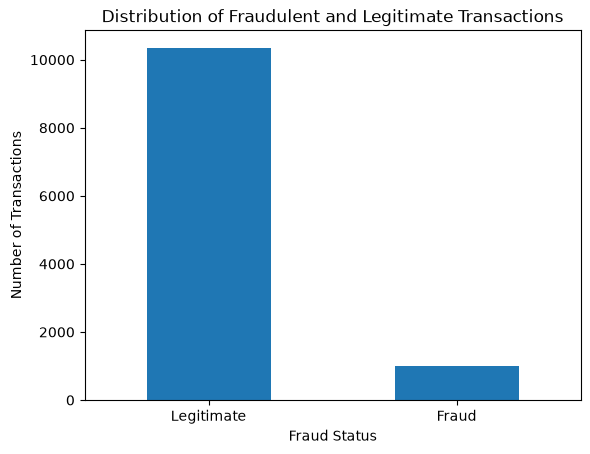

In [67]:


eda_df['is_fraud'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribution of Fraudulent and Legitimate Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.show()

### 4.2 Numerical Features by Fraud Class

Means and medians are compared between legitimate and fraudulent transactions. Medians provide a robust description when distributions are skewed, while the difference between mean and median helps reveal the influence of extreme values.

In [68]:
numeric_features = [
    'amount_usd',
    'fee',
    'exchange_rate_src_to_dest',
    'ip_risk_score',
    'account_age_days',
    'device_trust_score',
    'chargeback_history_count',
    'risk_score_internal',
    'txn_velocity_1h',
    'txn_velocity_24h',
    'corridor_risk'
]

In [69]:
# The median table 

numeric_fraud_summary = (
    eda_df
    .groupby('is_fraud')[numeric_features]
    .median()
    .T
)

numeric_fraud_summary.columns = [
    'legitimate_median',
    'fraud_median'
]

numeric_fraud_summary['difference'] = (
    numeric_fraud_summary['fraud_median'] -
    numeric_fraud_summary['legitimate_median']
)

numeric_fraud_summary

,legitimate_median,fraud_median,difference
amount_usd,151.705000,544.880000,393.175000
fee,3.330000,9.260000,5.930000
exchange_rate_src_to_dest,7.142857,58.823529,51.680672
ip_risk_score,0.307000,1.000000,0.693000
account_age_days,298.000000,21.000000,-277.000000
device_trust_score,0.744000,0.238000,-0.506000
chargeback_history_count,0.000000,0.000000,0.000000
risk_score_internal,0.223000,0.538000,0.315000
txn_velocity_1h,0.000000,4.000000,4.000000
txn_velocity_24h,0.000000,6.000000,6.000000


In [70]:
# Calculate means for legitimate and fraudulent transactions
mean_summary = (
    transactions_df
    .groupby('is_fraud')[numeric_features]
    .mean()
    .T
    .rename(columns={
        0: 'legitimate_mean',
        1: 'fraud_mean'
    })
)

# Calculate medians for legitimate and fraudulent transactions
median_summary = (
    transactions_df
    .groupby('is_fraud')[numeric_features]
    .median()
    .T
    .rename(columns={
        0: 'legitimate_median',
        1: 'fraud_median'
    })
)

# Join the two tables
numerical_comparison = mean_summary.join(median_summary)

# Arrange the columns
numerical_comparison = numerical_comparison[
    [
        'legitimate_mean',
        'legitimate_median',
        'fraud_mean',
        'fraud_median'
    ]
]

numerical_comparison.round(3)

is_fraud,legitimate_mean,legitimate_median,fraud_mean,fraud_median
amount_usd,394.183,151.705,1025.683,544.880
fee,6.897,3.330,16.140,9.260
exchange_rate_src_to_dest,149.630,7.143,355.765,58.824
ip_risk_score,0.353,0.307,0.851,1.000
account_age_days,424.073,298.000,79.683,21.000
device_trust_score,0.687,0.744,0.314,0.238
chargeback_history_count,0.002,0.000,0.530,0.000
risk_score_internal,0.240,0.223,0.545,0.538
txn_velocity_1h,0.133,0.000,3.845,4.000
txn_velocity_24h,0.268,0.000,5.478,6.000


In [71]:
invalid_fee_rows = transactions_df[
    (transactions_df['fee'] < 0) |
    (transactions_df['fee'] == 9999.99)
]

invalid_fee_rows[
    [
        'amount_src',
        'amount_usd',
        'fee',
        'channel',
        'is_fraud'
    ]
]

,amount_src,amount_usd,fee,channel,is_fraud


### 4.3 Categorical Features

Categorical variables are analysed using transaction count, fraud count, fraud rate, and fraud lift. This is more appropriate than Pearson correlation for nominal text categories.

In [72]:
categorical_features = [
    'home_country',
    'source_currency',
    'dest_currency',
    'channel',
    'new_device',
    'ip_country',
    'location_mismatch',
    'kyc_tier'
]

In [73]:
def category_fraud_summary(df, column):
    summary = (
        df.groupby(column, dropna=False)['is_fraud']
        .agg(
            transaction_count='count',
            fraud_count='sum',
            fraud_rate='mean'
        )
        .reset_index()
    )

    summary['fraud_rate_percentage'] = (
        summary['fraud_rate']
        .mul(100)
        .round(2)
    )

    return summary.sort_values(
        'fraud_rate_percentage',
        ascending=False
    )

### 4.4 Numerical Correlation with Fraud

Pearson correlation is used as a screening tool for numerical and Boolean variables. The analysis focuses on linear association with the target and should be interpreted alongside domain knowledge and the grouped summaries.

In [74]:
transactions_df.corr(
    numeric_only=True
)['is_fraud'].sort_values(ascending=False)

is_fraud                      1.000000
txn_velocity_24h              0.751737
txn_velocity_1h               0.688367
risk_score_internal           0.602002
chargeback_history_count      0.581129
ip_risk_score                 0.520355
location_mismatch             0.418109
new_device                    0.378426
corridor_risk                 0.193732
exchange_rate_src_to_dest     0.152592
amount_src                    0.128438
amount_usd                    0.127897
fee                           0.124771
device_trust_score_missing   -0.035024
ip_address_missing           -0.036151
account_age_days             -0.284659
device_trust_score           -0.390182
Name: is_fraud, dtype: float64

In [75]:
fraud_correlations = (
    transactions_df
    .corr(numeric_only=True)['is_fraud']
    .drop('is_fraud')
    .sort_values(key=abs, ascending=False)
)

fraud_correlations

txn_velocity_24h              0.751737
txn_velocity_1h               0.688367
risk_score_internal           0.602002
chargeback_history_count      0.581129
ip_risk_score                 0.520355
location_mismatch             0.418109
device_trust_score           -0.390182
new_device                    0.378426
account_age_days             -0.284659
corridor_risk                 0.193732
exchange_rate_src_to_dest     0.152592
amount_src                    0.128438
amount_usd                    0.127897
fee                           0.124771
ip_address_missing           -0.036151
device_trust_score_missing   -0.035024
Name: is_fraud, dtype: float64

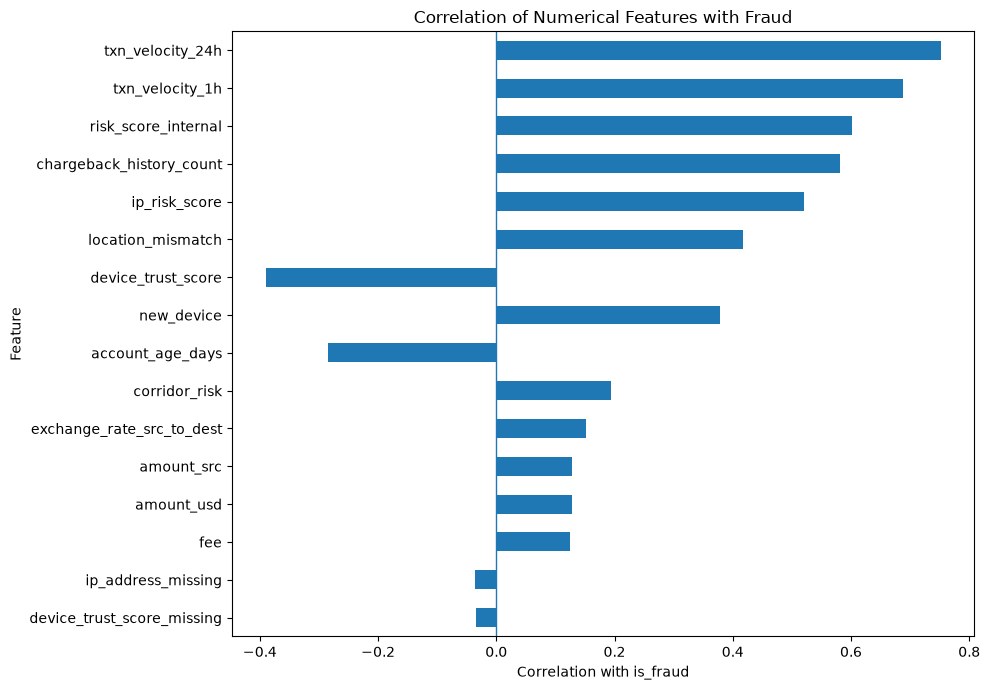

In [76]:
import matplotlib.pyplot as plt

# Calculate correlation of numerical columns with the fraud target
fraud_correlations = (
    transactions_df
    .corr(numeric_only=True)['is_fraud']
    .drop('is_fraud')
)

# Arrange features from weakest to strongest correlation
fraud_correlations = fraud_correlations.reindex(
    fraud_correlations.abs().sort_values().index
)

# Plot
plt.figure(figsize=(10, 7))

fraud_correlations.plot(kind='barh')

plt.axvline(0, linewidth=1)
plt.title('Correlation of Numerical Features with Fraud')
plt.xlabel('Correlation with is_fraud')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The correlation chart ranks numerical and Boolean features by the strength and direction of their linear relationship with `is_fraud`. Correlation does not establish causation, and a low coefficient does not necessarily mean a feature will be unhelpful to a nonlinear model.

### 4.5 Feature Interactions

Individual features may become more informative when they occur together. The following analysis examines the combined effect of a new device and a location mismatch on fraud rate.

In [77]:
device_location_summary = (
    transactions_df
    .groupby(
        ['new_device', 'location_mismatch']
    )['is_fraud']
    .agg(
        transaction_count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )
    .reset_index()
)

# Convert fraud rate to percentage
device_location_summary['fraud_rate_percentage'] = (
    device_location_summary['fraud_rate']
    .mul(100)
    .round(2)
)

device_location_summary

,new_device,location_mismatch,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage
0,False,False,8635,221,0.025594,2.56
1,False,True,1357,263,0.193810,19.38
2,True,False,859,117,0.136205,13.62
3,True,True,488,394,0.807377,80.74


In [78]:
device_location_plot = (
    device_location_summary
    .pivot(
        index='new_device',
        columns='location_mismatch',
        values='fraud_rate_percentage'
    )
)

device_location_plot

location_mismatch,False,True
new_device,,
False,2.56,19.38
True,13.62,80.74


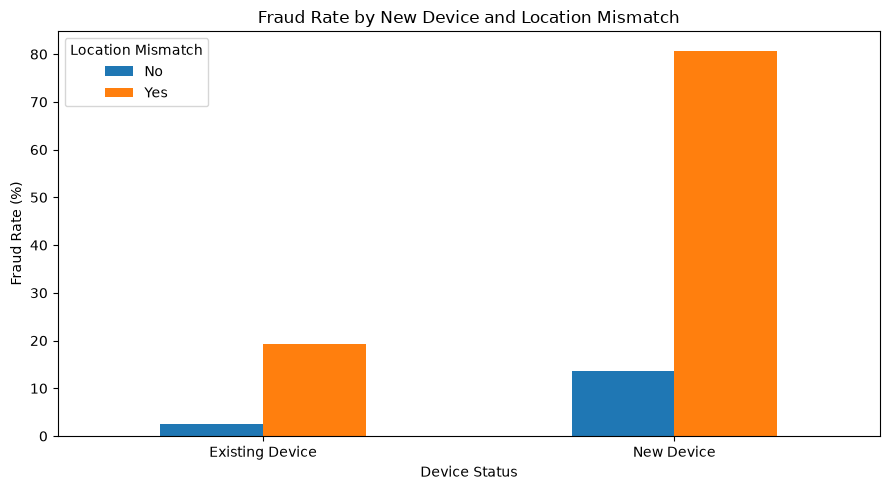

In [79]:
import matplotlib.pyplot as plt

device_location_plot.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Fraud Rate by New Device and Location Mismatch')
plt.xlabel('Device Status')
plt.ylabel('Fraud Rate (%)')

plt.xticks(
    ticks=[0, 1],
    labels=['Existing Device', 'New Device'],
    rotation=0
)

plt.legend(
    title='Location Mismatch',
    labels=['No', 'Yes']
)

plt.tight_layout()
plt.show()

### 4.6 Fraud Rate by KYC Tier

Fraud rates are compared across KYC categories while retaining transaction counts so that very small groups are not overinterpreted.

In [80]:
kyc_summary = (
    eda_df
    .groupby('kyc_tier', dropna=False)['is_fraud']
    .agg(
        transaction_count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )
    .reset_index()
)

kyc_summary['fraud_rate_percentage'] = (
    kyc_summary['fraud_rate']
    .mul(100)
    .round(2)
)

kyc_summary = kyc_summary.sort_values(
    'fraud_rate_percentage',
    ascending=False
)

kyc_summary

,kyc_tier,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage
1,low,1059,536,0.506138,50.61
2,standard,8350,418,0.050060,5.01
0,enhanced,1928,41,0.021266,2.13
3,unknown,2,0,0.000000,0.00


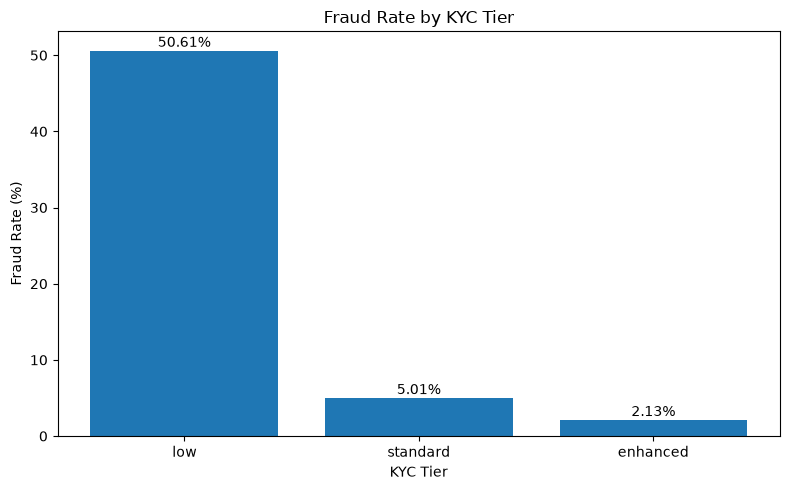

In [81]:
# Keep categories with a meaningful number of transactions
kyc_plot = kyc_summary[
    kyc_summary['transaction_count'] > 2
].copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    kyc_plot['kyc_tier'],
    kyc_plot['fraud_rate_percentage']
)

plt.title('Fraud Rate by KYC Tier')
plt.xlabel('KYC Tier')
plt.ylabel('Fraud Rate (%)')

# Add percentage labels
for bar, rate in zip(
    bars,
    kyc_plot['fraud_rate_percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### KYC-Tier Interpretation

Transactions in the low KYC tier recorded the highest fraud rate, compared with substantially lower rates for standard and enhanced KYC. This pattern suggests that stronger customer verification is associated with lower observed fraud in this dataset.

The `unknown` category is excluded from the visual comparison because it contains only two transactions and is therefore too small to support a reliable conclusion.

### 4.7 Fraud Rate by 24-Hour Transaction Velocity

The analysis examines whether fraud risk changes as the number of transactions completed within 24 hours increases.

In [82]:
velocity_24h_summary = (
    eda_df
    .groupby('txn_velocity_24h')['is_fraud']
    .agg(
        transaction_count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )
    .reset_index()
)

velocity_24h_summary['fraud_rate_percentage'] = (
    velocity_24h_summary['fraud_rate']
    .mul(100)
    .round(2)
)

velocity_24h_summary

,txn_velocity_24h,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage
0,0,9199,167,0.018154,1.82
1,1,856,14,0.016355,1.64
2,2,167,0,0.000000,0.00
3,3,71,3,0.042254,4.23
4,4,139,79,0.568345,56.83
5,5,165,128,0.775758,77.58
6,6,253,200,0.790514,79.05
7,7,191,154,0.806283,80.63
8,8,167,122,0.730539,73.05
9,9,84,81,0.964286,96.43


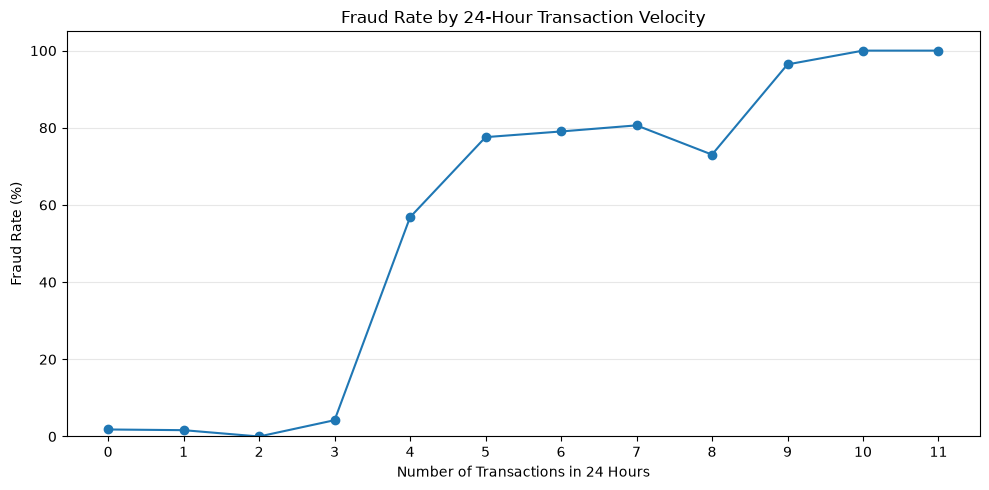

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    velocity_24h_summary['txn_velocity_24h'],
    velocity_24h_summary['fraud_rate_percentage'],
    marker='o'
)

plt.title('Fraud Rate by 24-Hour Transaction Velocity')
plt.xlabel('Number of Transactions in 24 Hours')
plt.ylabel('Fraud Rate (%)')

plt.xticks(
    velocity_24h_summary['txn_velocity_24h']
)

plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Transaction-Velocity Interpretation

Fraud remained uncommon when transaction velocity was between zero and two transactions within 24 hours. The fraud rate increased sharply from a velocity of four and remained high across most larger velocity groups.

This indicates that unusually frequent transaction activity is a strong fraud indicator in the dataset. The 100% fraud rates at velocities of 10 and 11 should be interpreted cautiously because those groups contain relatively few transactions.

### 4.8 Remaining Categorical Features

The remaining categorical variables are summarised using fraud rate and fraud lift relative to the overall fraud rate. Categories with very small sample sizes should be interpreted cautiously.

In [84]:
overall_fraud_rate = eda_df['is_fraud'].mean()

categorical_summaries = {}

for column in categorical_features:

    summary = (
        eda_df
        .groupby(column, dropna=False)['is_fraud']
        .agg(
            transaction_count='count',
            fraud_count='sum',
            fraud_rate='mean'
        )
        .reset_index()
    )

    summary['fraud_rate_percentage'] = (
        summary['fraud_rate'] * 100
    ).round(2)

    summary['fraud_lift'] = (
        summary['fraud_rate'] / overall_fraud_rate
    ).round(2)

    summary = summary.sort_values(
        'fraud_rate_percentage',
        ascending=False
    )

    categorical_summaries[column] = summary

    print(f'\nFraud analysis for: {column}')
    display(summary)


Fraud analysis for: home_country


,home_country,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage,fraud_lift
0,ca,1222,185,0.151391,15.14,1.73
1,uk,2120,280,0.132075,13.21,1.51
3,us,7965,529,0.066416,6.64,0.76
2,unknown,32,1,0.031250,3.12,0.36



Fraud analysis for: source_currency


,source_currency,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage,fraud_lift
0,cad,1224,185,0.151144,15.11,1.72
1,gbp,2127,281,0.132111,13.21,1.51
2,usd,7988,529,0.066224,6.62,0.75



Fraud analysis for: dest_currency


...

,ip_country,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage,fraud_lift
0,ca,1753,304,0.173417,17.34,1.98
1,uk,2472,360,0.145631,14.56,1.66
3,us,7048,331,0.046964,4.70,0.54
2,unknown,66,0,0.000000,0.00,0.00



Fraud analysis for: location_mismatch


,location_mismatch,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage,fraud_lift
1,True,1845,657,0.356098,35.61,4.06
0,False,9494,338,0.035601,3.56,0.41



Fraud analysis for: kyc_tier


,kyc_tier,transaction_count,fraud_count,fraud_rate,fraud_rate_percentage,fraud_lift
1,low,1059,536,0.506138,50.61,5.77
2,standard,8350,418,0.050060,5.01,0.57
0,enhanced,1928,41,0.021266,2.13,0.24
3,unknown,2,0,0.000000,0.00,0.00


#### Categorical Findings

Categorical analysis revealed substantial differences in fraud rates across customer and transaction characteristics. Low-KYC transactions recorded the highest fraud rate, while web transactions showed a higher fraud rate than ATM and mobile transactions. Transactions involving MXN and NGN as destination currencies also recorded above-average fraud rates.

New-device activity and location mismatch were particularly informative, and their combination produced the strongest categorical risk pattern. These findings indicate that verification level, transaction channel, currency corridor, and device-location behaviour may provide useful predictive information.

## 5. Overall EDA Findings

The exploratory analysis identified several patterns associated with fraudulent transactions:

- Fraudulent transactions generally had higher transaction amounts, IP risk scores, internal risk scores, and transaction velocities.
- Fraud was associated with newer accounts and lower device-trust scores.
- The fraud rate rose sharply at higher 24-hour transaction velocities.
- Low-KYC transactions had a substantially higher fraud rate than standard and enhanced KYC transactions.
- Web transactions and selected destination currencies showed above-average fraud rates.
- The combination of a new device and a location mismatch produced the strongest observed interaction.

These findings suggest that transaction frequency, customer verification level, account history, device trust, IP risk, currency corridor, and device-location behaviour may be valuable predictive features.

Before modelling, `risk_score_internal` should be reviewed for possible target leakage by confirming that it was available at transaction time and was not derived from the final fraud outcome.

## 6. Preparation for Modelling

A separate modelling DataFrame is created so that feature engineering and model preparation do not alter the cleaned analytical dataset. The next steps should include feature engineering, identifier removal, train/validation/test splitting, preprocessing fitted only on training data, baseline modelling, and evaluation with imbalance-aware metrics.

In [85]:
model_df = transactions_df.copy()

### 6.1 Removing Direct Identifiers

Direct identifiers such as transaction, customer, and device IDs should not be used as ordinary model inputs because they can encourage memorisation rather than generalisable fraud detection. Their removal should occur only after any legitimate customer- or device-level behavioural features have been engineered.

In [86]:
transactions_df= transactions_df.drop(columns=['transaction_id', 'customer_id','device_id'])